# Статистика, DS-поток
## Марафон-домашка SM.6, практическая часть

**Правила:**

* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Выполненную работу нужно отправить телеграм-боту. Для начала работы с ботом каждый раз отправляйте `/start`. Дождитесь подтверждения от бота, что он принял файл. Если подтверждения нет, то что-то не так. **Работы, присланные иным способом, не принимаются.**
* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно **ноутбук в формате `ipynb`**.
* Следите за размером файлов. **Бот не может принимать файлы весом более 20 Мб.** Если файл получается больше, заранее разделите его на несколько.
* Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания все участники списывания получат штраф.**
* Решения, размещенные на каких-либо интернет-ресурсах, не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Для выполнения задания используйте этот ноутбук в качестве основы, ничего не удаляя из него. Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*
* В каждой задаче не забывайте делать **пояснения и выводы**.
* **Код из рассказанных на занятиях ноутбуков** можно использовать без ограничений.


**Баллы за задание:**

* Задача 1 &mdash;  100 баллов
* Задача 2 &mdash;  120 баллов
* Задача 3 &mdash;  80 баллов

**Важность задач:**

* *высокая:* задачи 1-3.

<font color="red">**Напоминание**. В задачах могут быть "скрытые" критерии, то есть "заказчик" хочет что-то, что явно не указал в условии. Если вы внимательно следите за удобством восприятия информации в вашем решении, учитываете советы по оформлению и отрабатываете замечания проверяющих, вам не составит труда выполнить эти критерии.</font>

In [1]:
# Bot check

# HW_ID: ds_sm6
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: not final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

In [150]:
import numpy as np
import pandas as pd
import scipy.stats as sps
from tqdm.notebook import tqdm

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid", font_scale=1.3, palette=['#7570b3','#e7298a','#66a61e','#1b9e77','#e6ab02','#d95f02'])

### Ссылки на использование ИИ

Если при решении задач использовался ИИ, укажи здесь публичные ссылки на все чаты с ИИ и поясни, для каких целей он применялся. Обрати внимание на <a href="https://thetahat.ru/courses/ai-rules" target="_top">правила</a>.

**Задача 1**
1. ссылка
    - для чего использована
    - для чего использована
2. ссылка
    - для чего использована

**Задача 2**
1. ссылка
    - для чего использована

   ...
 

_____
### Задача 1.

В одной известной компании поставлена задача построения нейросети для распознавания котиков и песиков. Для построения такого бинарного классификатора собрана коллекция изображений со сбалансированными классами.

Прошел месяц работы аналитиков и ML-разработчиков, и, наконец-то, нейросеть обучена и готова к использованию. Но руководство хочет убедиться, что месяц работы прошел не зря, и построенная нейросеть действительно дает результат.
Как известно, случайный классификатор, выдающий для каждого объекта случайный класс, угадывает ответ правильно с вероятностью $1/2$. И руководству будет достаточно, если модель будет работать лучше. Однако, как их убедить в том, что та же точность 60% действительно отличается от 50%, а не вызвана чистой случайностью? На помощь приходит проверка статистических гипотез &mdash; вы можете проверить статистическую значимость отклонения от базовой точности 50%, и предъявить ее в качестве доказательства.

Сформулируем задачу на математическом языке. Пусть $X_1, ..., X_n \sim Bern(p)$ &mdash; результаты работы модели на тестовой выборке, где $X_i = 1$, если для $i$-го объекта модель правильно определила класс, а $p$ &mdash; неизвестная вероятность такого события.
Мы хотим проверить гипотезу $\mathsf{H}_0\colon p=1/2$ против альтернативы $\mathsf{H}_1\colon p>1/2$. Нулевая гипотеза означает, что построенный классификатор выдает рандомный ответ, а первая &mdash; что чаще все же выдает верный ответ.

На семинаре получено, что $S = \left\{T(x) \geqslant c_\alpha\right\}$, где $T(X) = \sum\limits_{i=1}^n X_i$, является равномерно наиболее мощным критерием для проверки этих гипотез.
Чему при этом равно $c_\alpha$? Учтите, что распределение дискретное, и строгий/нестрогий знак имеет значение.

In [6]:
import base64
from IPython.display import Markdown, display
def embed_image(filename):
    with open(filename, "rb") as f:
        data = base64.b64encode(f.read()).decode()
    md = f'<img src="data:image/png;base64,{data}" width="800">'
    display(Markdown(md))

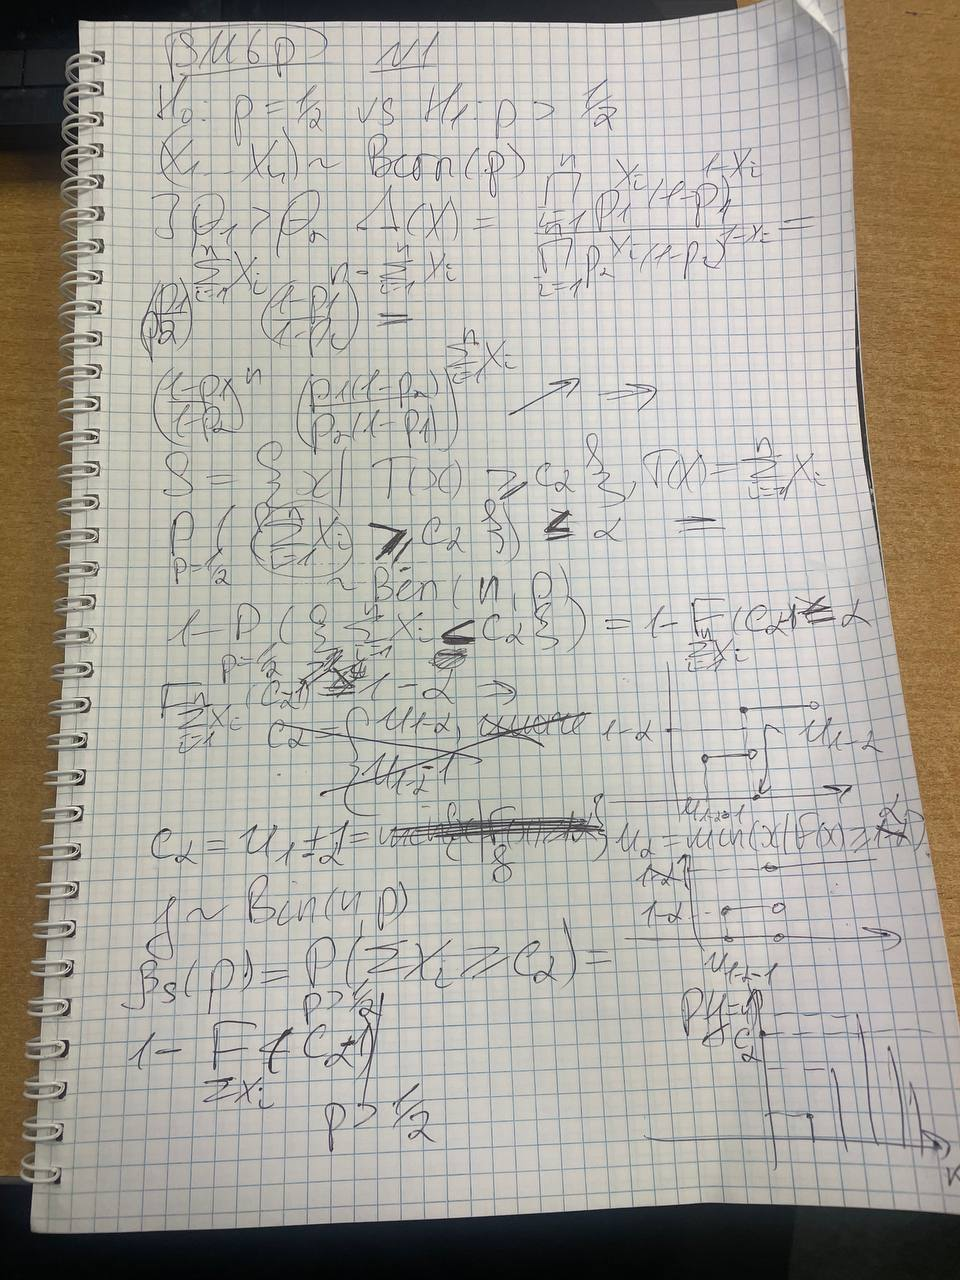

In [246]:
embed_image('1.jpg')

Проверьте, что критерий работает.
Возьмите несколько значений $n$ и реализаций статистики $T(X)$.
В каждом случае найдите значение $c_\alpha$, а также выведите результат процедуры проверки гипотез 0/1 &mdash; отвергается ли $\mathsf{H}_0$ (выводите 1, если отвергается).
Оформите это в виде таблицы, можно через `pandas.DataFrame`.

*Замечание:* Пользуйтесь функциями из `scipy.stats`.

In [243]:
p = 0.5
alpha = 0.05

n1 = 20
n2 = 50
n3 = 100

t1 = sps.binom(n1, p).rvs(size=1)[0]
t2 = sps.binom(n2, p).rvs(size=1)[0]
t3 = sps.binom(n3, p).rvs(size=1)[0]

c1 = sps.binom(n1, p).ppf(1 - alpha) + 1
c2 = sps.binom(n2, p).ppf(1 - alpha) + 1
c3 = sps.binom(n3, p).ppf(1 - alpha) + 1

pd.DataFrame({'n': [n1, n2, n3], 'T(X)': [t1, t2, t3], '$c_\\alpha$': [c1, c2, c3], 
              'Result': [int(t1 >= c1), int(t2 >= c2), int(t3 >= c3)]})

,n,T(X),$c_\alpha$,Result
0,20,10,15.0,0
1,50,25,32.0,0
2,100,46,59.0,0


Теперь для некоторых $n$ постройте графики функции мощности критерия при $1/2 < p < 1$ и уровне значимости 0.05. Сравните их.

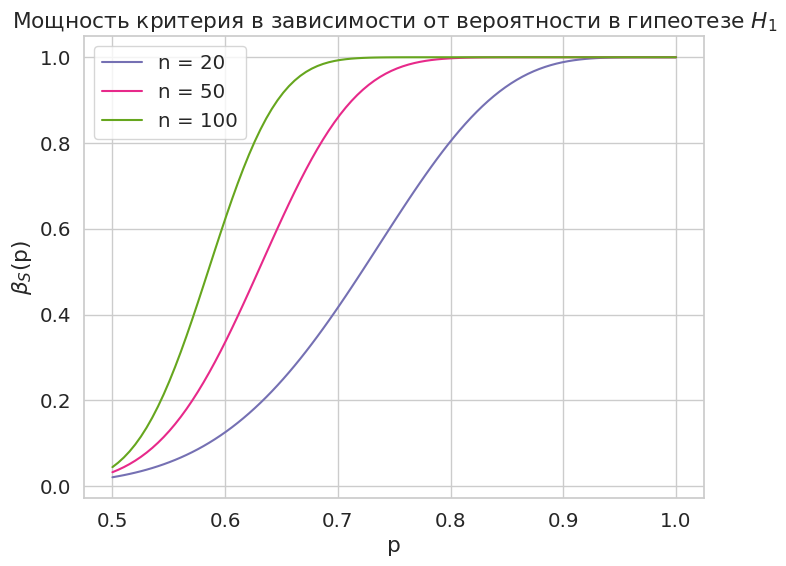

In [244]:
p_grid = np.linspace(0.5, 1, 100)
plt.figure(figsize=(8, 6))
for n in [n1, n2, n3]:
    plt.plot(p_grid, 1 - sps.binom(n, p_grid).cdf(sps.binom(n, p).ppf(1 - alpha)),
            label=f'n = {n}', )
    
plt.legend()
plt.title(r'Мощность критерия в зависимости от вероятности в гипеотезе $H_1$')
plt.ylabel(r'$\beta_S$(p)')
plt.xlabel('p')
plt.show()

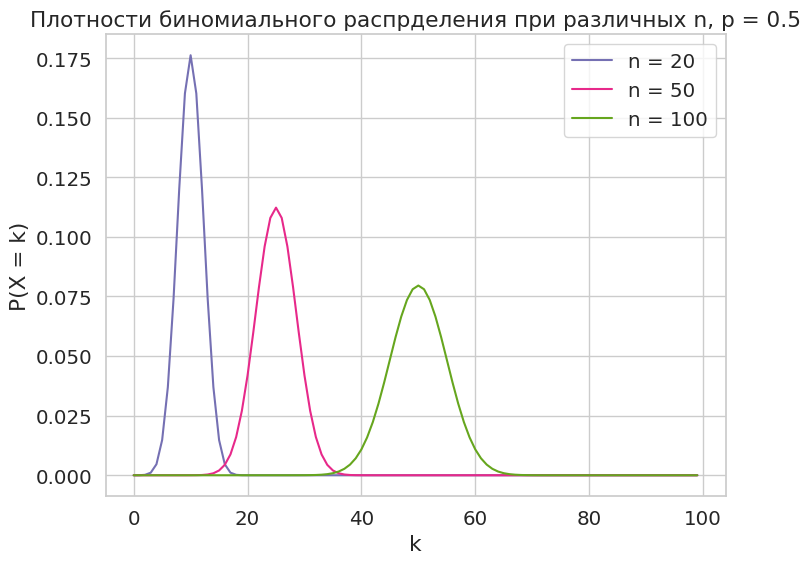

In [245]:
x_grid = np.arange(0, 100)
plt.figure(figsize=(8, 6))
for n in [n1, n2, n3]:
    plt.plot(x_grid, sps.binom(n, p).pmf(x_grid),
            label=f'n = {n}', )
    
plt.legend()
plt.title(r'Плотности биномиального распрделения при различных n, p = 0.5')
plt.ylabel(r'P(X = k)')
plt.xlabel('k')
plt.show()

**Вывод:** Видим, что мощность, то есть вероятность отвержения гипотезы, при условии, что $H_0$ не верна, сначала равна вероятности ошибки первого рода, которая ограниченая $\alpha$, а с ростом p быстро увеличивается до 1. Это связано с тем, что по мере увеличения этой самой вероятности, мы всё более уверены, что гипотезу можно отвергнуть, потому что наша статистика всё с большей вероятностью будет больше чем фиксированное число $c_\alpha$, например, так как матожидание биномиального распрделения есть np.  А значит наша статистика, которая есть реализация случайной величины с матожиданием np, будет всё с большей вероятностью отвергнута. Аналогично объясняется зависимость скорости роста мощности от n: очевидно из матожидания 

_____
### Задача 2.

На практике часто рассматривают асимптотические критерии, например, критерий Вальда. Такие критерии контролируют вероятность ошибки I рода на уровне $\alpha$ только в пределе, однако для небольших выборок она может сильно отличаться от $\alpha$, причем не редко в большую сторону. Поэтому для таких критериев возникает необходимость в вычислении значения вероятности ошибки I рода при конечной выборке.

Зачастую посчитать точное значение вероятности ошибки I рода довольно сложно, поэтому вместо него вычисляют оценку с помощью семплирования по методу Монте-Карло.

Пусть гипотеза $\mathsf{H}_0$ простая, то есть $\mathsf{H}_0\colon \mathsf{P} = \mathsf{P}_0$. Для ее проверки по конечной выборке $X_1, ..., X_n$ используется критерий $S$. **Опишите схему оценки вероятности ошибки I рода** критерия $S$ методом Монте-Карло.

Ошибка первого рода - супремум вероятности по всем распредлениям $P_0$, в данном случае, одному отвергнуть гипотезу $H_0$, когда она на самом деле верна, то есть $\sup_{\mathsf{P} = \mathsf{P}_0} P(X \in S)$ = $P_0(X \in S)$. Методом Монте-Карло мы должно посчитать долю $X_i \in S$ от всей просэмплированной выборки размера n

Если гипотеза $\mathsf{H}_0$ сложная, то есть $\mathsf{H}_0\colon \mathsf{P} \in \mathscr{P}_0$, то можно повторить такую процедуру несколько раз для разных $\mathsf{P} \in \mathscr{P}_0$.

Рассмотрим альтернативную гипотезу $\mathsf{H}_1\colon \mathsf{P} \in \mathscr{P}_1$. **Опишите схему оценки мощности** критерия $S$ методом Монте-Карло.

Мощность есть функция от распределения $\mathsf{P}$: $\beta_S(\mathsf{P})|_{\mathsf{P} \in \mathscr{P}_1} = P(X \in S)|_{\mathsf{P} \in \mathscr{P}_1}$. Для её оценки методом Монте-Карло будем брать случайное распрделение m раз, получать из него X, и считать долю $X \in S$

Пусть $X_1, ..., X_n$ &mdash; выборка из пуассоновского распределения с параметром $\theta$. Рассмотрим гипотезы $\mathsf{H}_0\colon \theta = 1\ \ vs.\ \ \mathsf{H}_1\colon \theta \not= 1$ и критерий Вальда для их проверки.

**1.** **Оцените вероятности ошибки I рода** критерия для размеров выборки $1 \leqslant n \leqslant 50$ и визуализируйте полученную зависимость.

  0%|          | 0/50 [00:00<?, ?it/s]

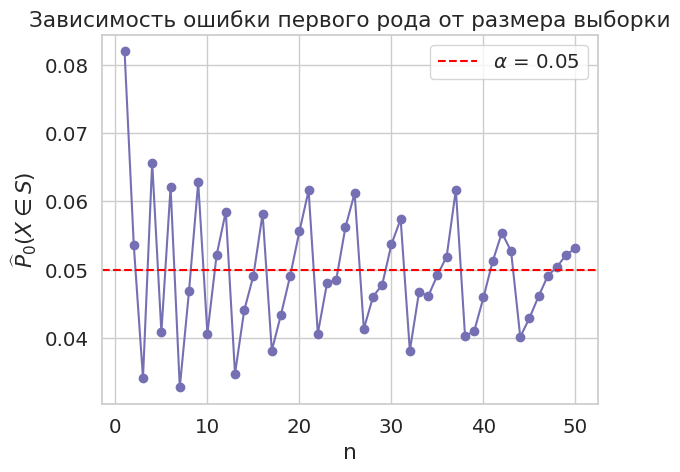

In [333]:
n_grid = np.arange(1, 51)
p_1 = []

t_0 = 1.0
alpha = 0.05
z = sps.norm.ppf(1 - alpha / 2)  

m = 10_000 

for n in tqdm(n_grid):
    x = sps.poisson(mu=t_0).rvs(size=(m, n))
    x_mean = np.mean(x, axis=1)
    W = np.sqrt(n) * (x_mean - t_0) / np.sqrt(t_0)   
    p_1.append(np.mean(np.abs(W) > z))

plt.plot(n_grid, p_1, marker='o')
plt.axhline(alpha, c='r', linestyle='--', label=rf'$\alpha$ = {alpha}')
plt.xlabel('n')
plt.ylabel(r'$\widehat{P}_0(X \in S)$')
plt.title('Зависимость ошибки первого рода от размера выборки')
plt.legend()
plt.show()

**Вывод:** Видим, что с ростом выборки вероятность всё ближе колеблется около 0.05, но особенно при малых значениях бывает сильно больше этого порога

**2.** Для значений $n \in \{5, 15, 50\}$ **оцените функцию мощности критерия** для значений $\theta \in (0, 5)$ по сетке с шагом 0.01 по методу Монте-Карло. Визуализируйте полученные зависимости.

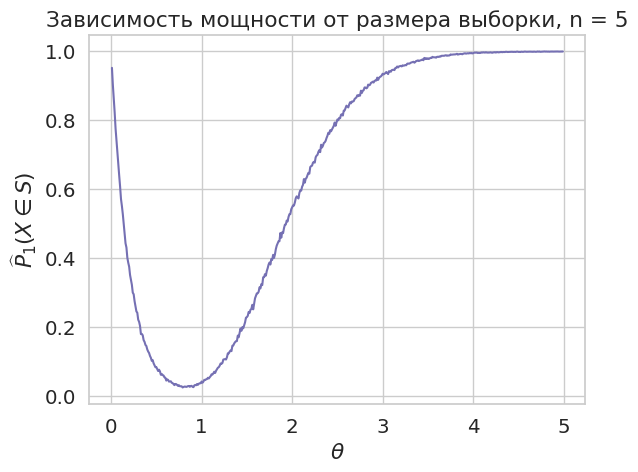

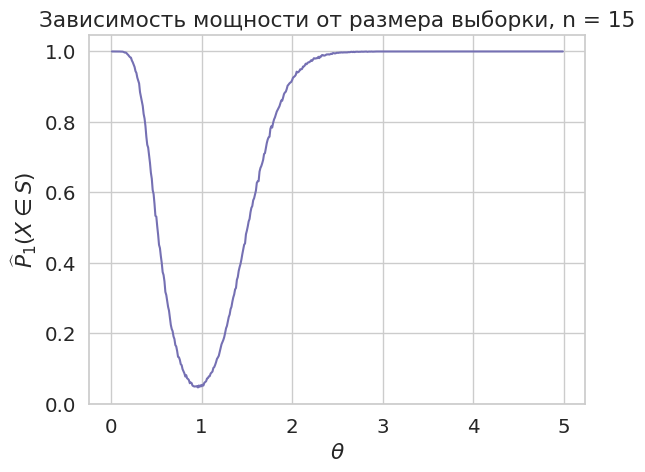

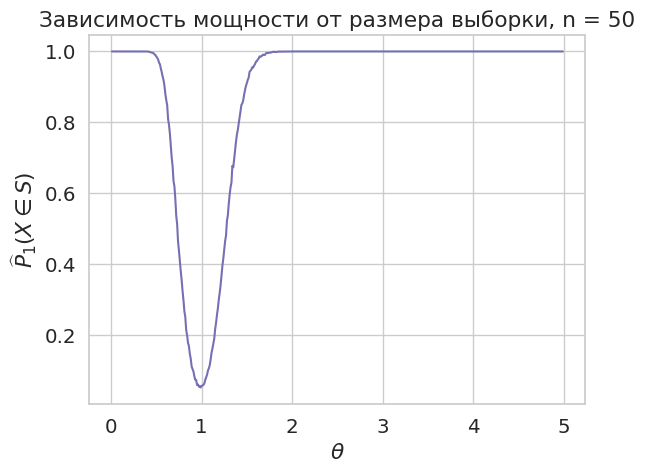

In [451]:
n_grid = [5, 15, 50]

def power(n):
    t_0 = 1.0
    m = 10_000
    alpha = 0.05
    z = sps.norm.ppf(1 - alpha / 2)  
    theta_grid = np.arange(0.01, 5, 0.01)
    beta = []
    
    for t in theta_grid:
        x = sps.poisson(mu=t).rvs(size=(m, n))
        x_mean = np.mean(x, axis=1)
        W = np.sqrt(n) * (x_mean - t_0) / np.sqrt(t_0)   
        beta.append(np.mean(np.abs(W) > z))

    plt.plot(theta_grid, beta)
    plt.xlabel(r'$\theta$')
    plt.ylabel(r'$\widehat{P}_1(X \in S)$')
    plt.title(f'Зависимость мощности от размера выборки, n = {n}')
    plt.show()

for n in n_grid:
    power(n)

**Вывод:** Аналогично, с ростом выборки n функция мощности становится более резкая

**3.** Пусть $n=50$. **Сравните мощности критериев**, соответствующих двусторонней, левосторонней и правосторонней альтернативам.

In [453]:
n = 50
t_0 = 1.0
m = 10_000
alpha = 0.05 
theta_grid = np.arange(0.01, 5, 0.01)
beta1 = []
beta2 = []
beta3 = []

z = sps.norm.ppf(1 - alpha / 2) 
for t in theta_grid:
    x = sps.poisson(mu=t).rvs(size=(m, n))
    x_mean = np.mean(x, axis=1)
    W = np.sqrt(n) * (x_mean - t_0) / np.sqrt(t_0)   
    beta1.append(np.mean(np.abs(W) > z))

z = sps.norm.ppf(1 - alpha)  
for t in theta_grid:
    x = sps.poisson(mu=t).rvs(size=(m, n))
    x_mean = np.mean(x, axis=1)
    W = np.sqrt(n) * (x_mean - t_0) / np.sqrt(t_0)   
    beta2.append(np.mean(W > z))

z = sps.norm.ppf(alpha)  
for t in theta_grid:
    x = sps.poisson(mu=t).rvs(size=(m, n))
    x_mean = np.mean(x, axis=1)
    W = np.sqrt(n) * (x_mean - t_0) / np.sqrt(t_0)   
    beta3.append(np.mean(W < z))

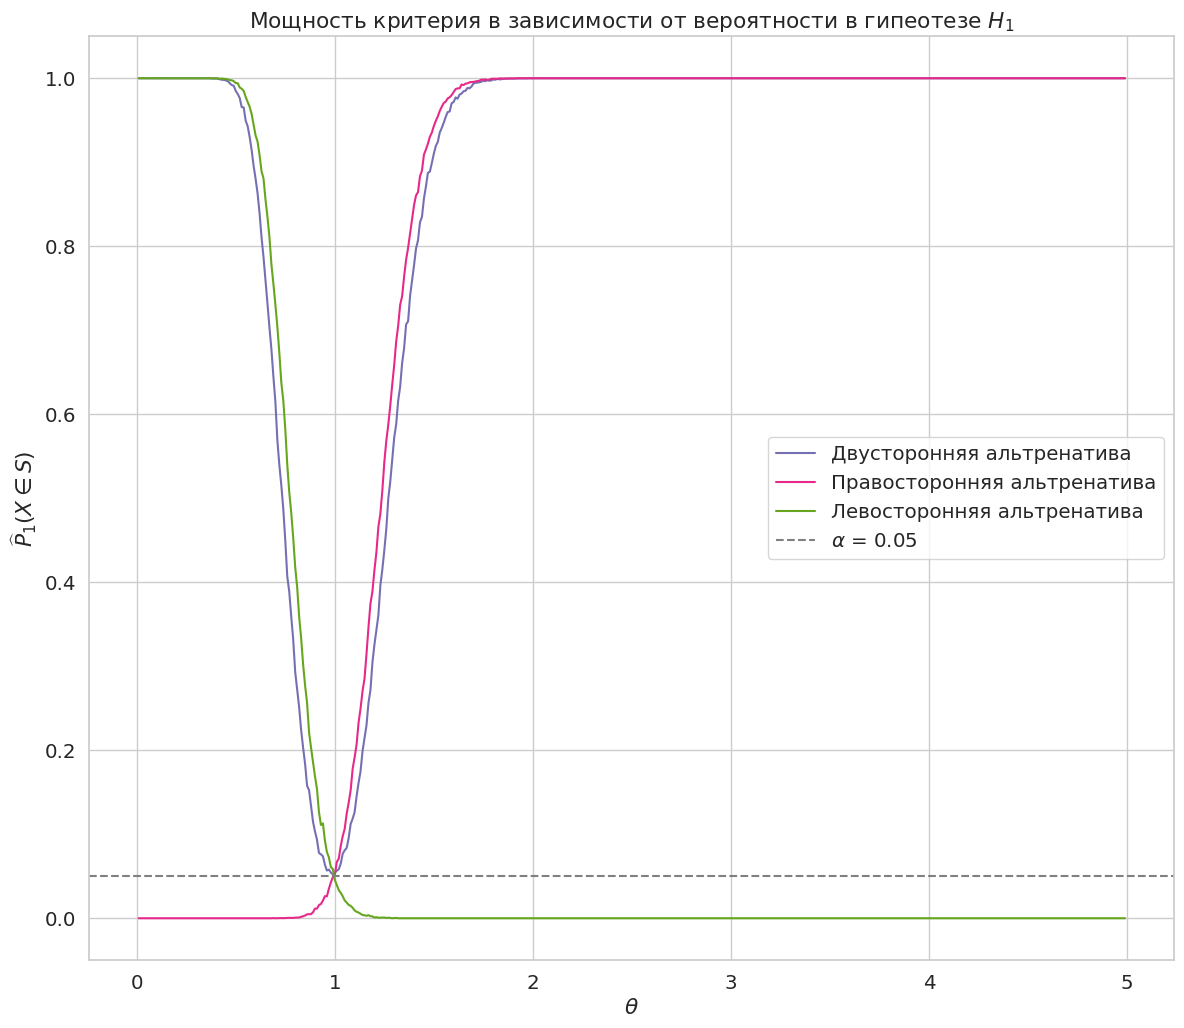

In [457]:
plt.figure(figsize=(14, 12))
plt.plot(theta_grid, beta1, label='Двусторонняя альтренатива')
plt.plot(theta_grid, beta2, label='Правосторонняя альтренатива')
plt.plot(theta_grid, beta3, label='Левосторонняя альтренатива')
plt.axhline(0.05, label=r'$\alpha$ = 0.05', color='gray', linestyle='--')
plt.xlabel(r'$\theta$')
plt.ylabel(r'$\widehat{P}_1(X \in S)$')
plt.title(r'Мощность критерия в зависимости от вероятности в гипеотезе $H_1$')
plt.legend()
plt.show()

**Вывод:** Видим, что односторонние альтернативы монотонны, в то врмемя как двусторонняя - нет. Это связано с формулировкой. Все они пересекаются примерно в одной точке при параметре $\theta = 1$, что соотвествует $\alpha$, вероятности ошибки первого рода, сама точкан е принадлежит области определния, выколотая. А дальше односторонние альтренативы изменяются быстрее, то есть в одностороннем случае мы более уверены в верном отвержении гипотезы, так как есть некоторое перекрытие в двустороннем случае как бы с противоположного конца.

**Вопрос на подумать.** Сколько семплирований в методе Монте-Карло нужно сделать, чтобы оценить вероятности ошибки I рода с точностью до 0.001? Иначе говоря, значения (0.049, 0.051) можно принять за 0.05.

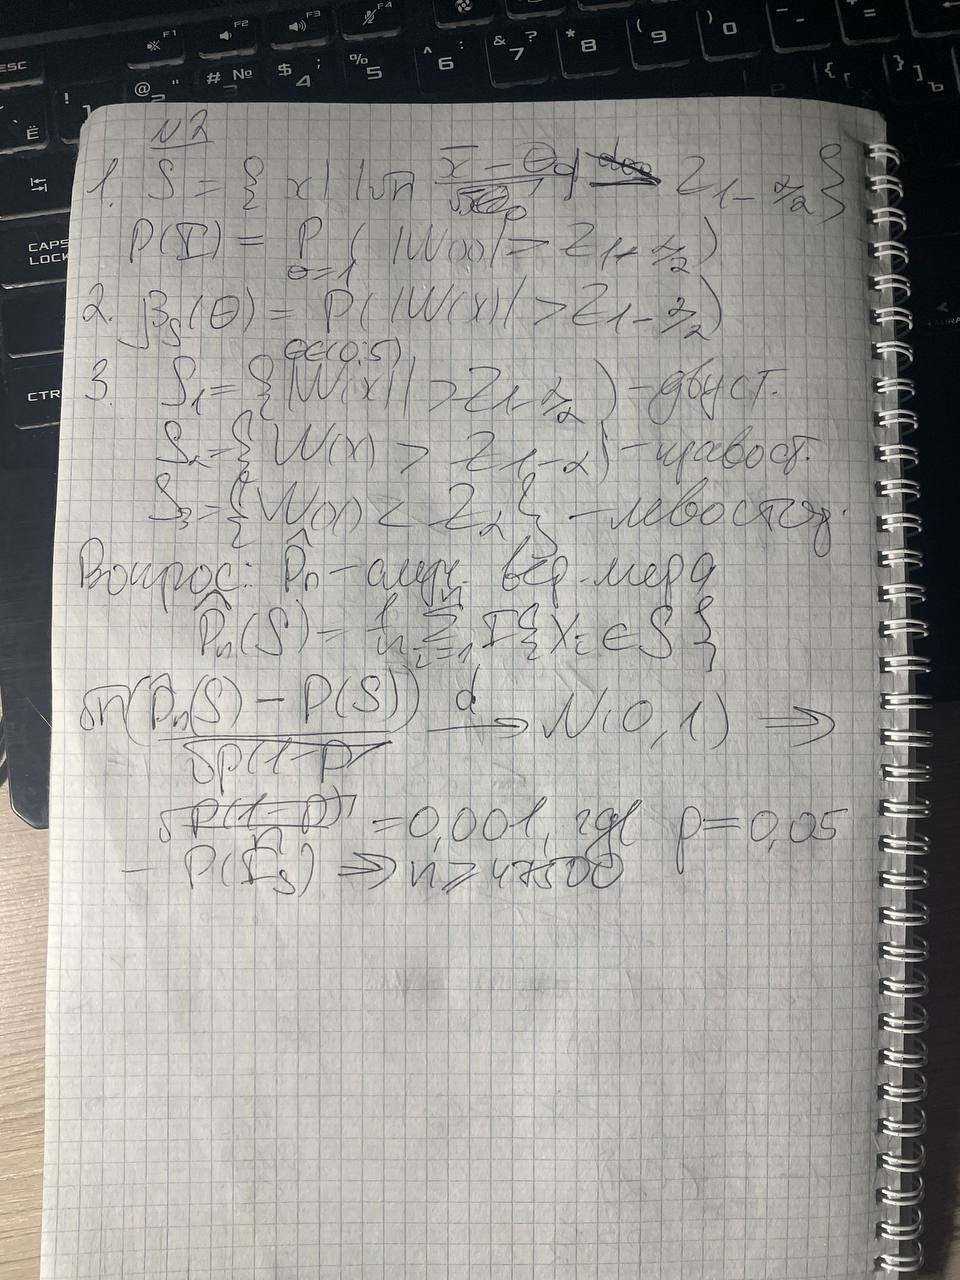

In [354]:
embed_image('2.jpg')

_____
### Задача 3.

Пусть $X_1, ..., X_n$ &mdash; выборка из распределения $\Gamma(\theta, \beta)$. Рассмотрим основную гипотезу $\mathsf{H}_0\colon \theta = 2$.

**1.** Пусть $\beta$ неизвестно. Для размеров выборки $n \in \{5, 15, 30, 50, 100\}$ **оцените вероятности ошибки I рода** критерия Вальда для двусторонней альтернативы в зависимости от истинных значений $\beta$. Визуализируйте полученные зависимости.

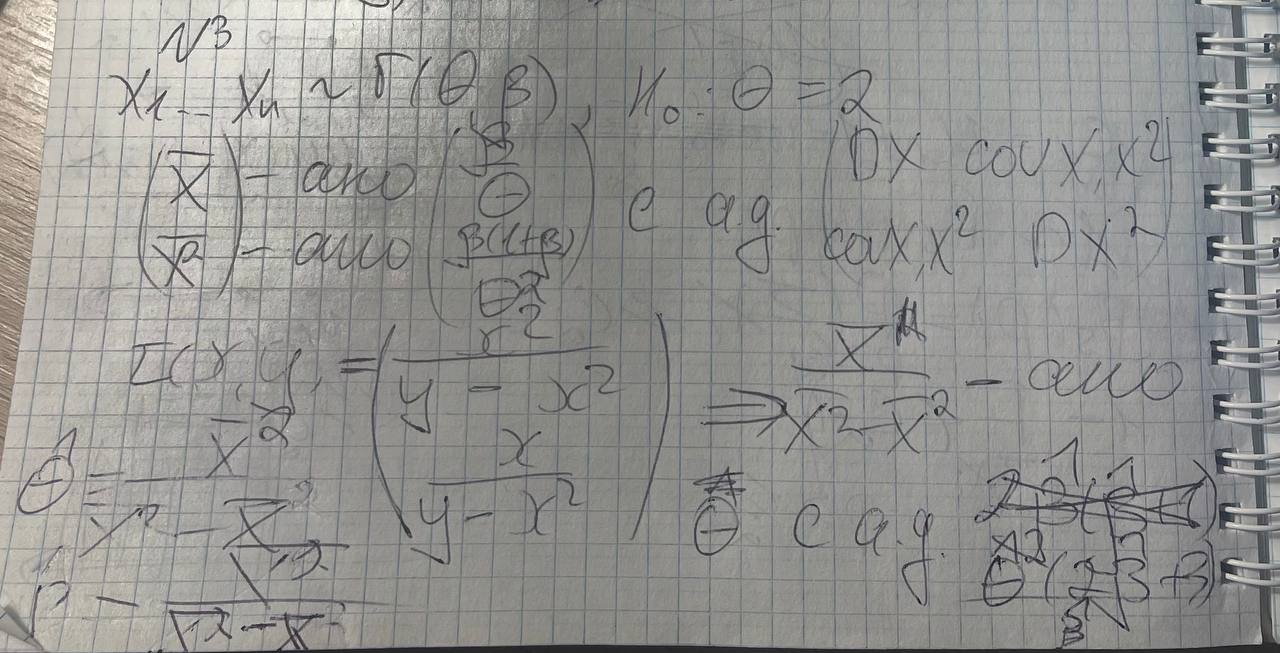

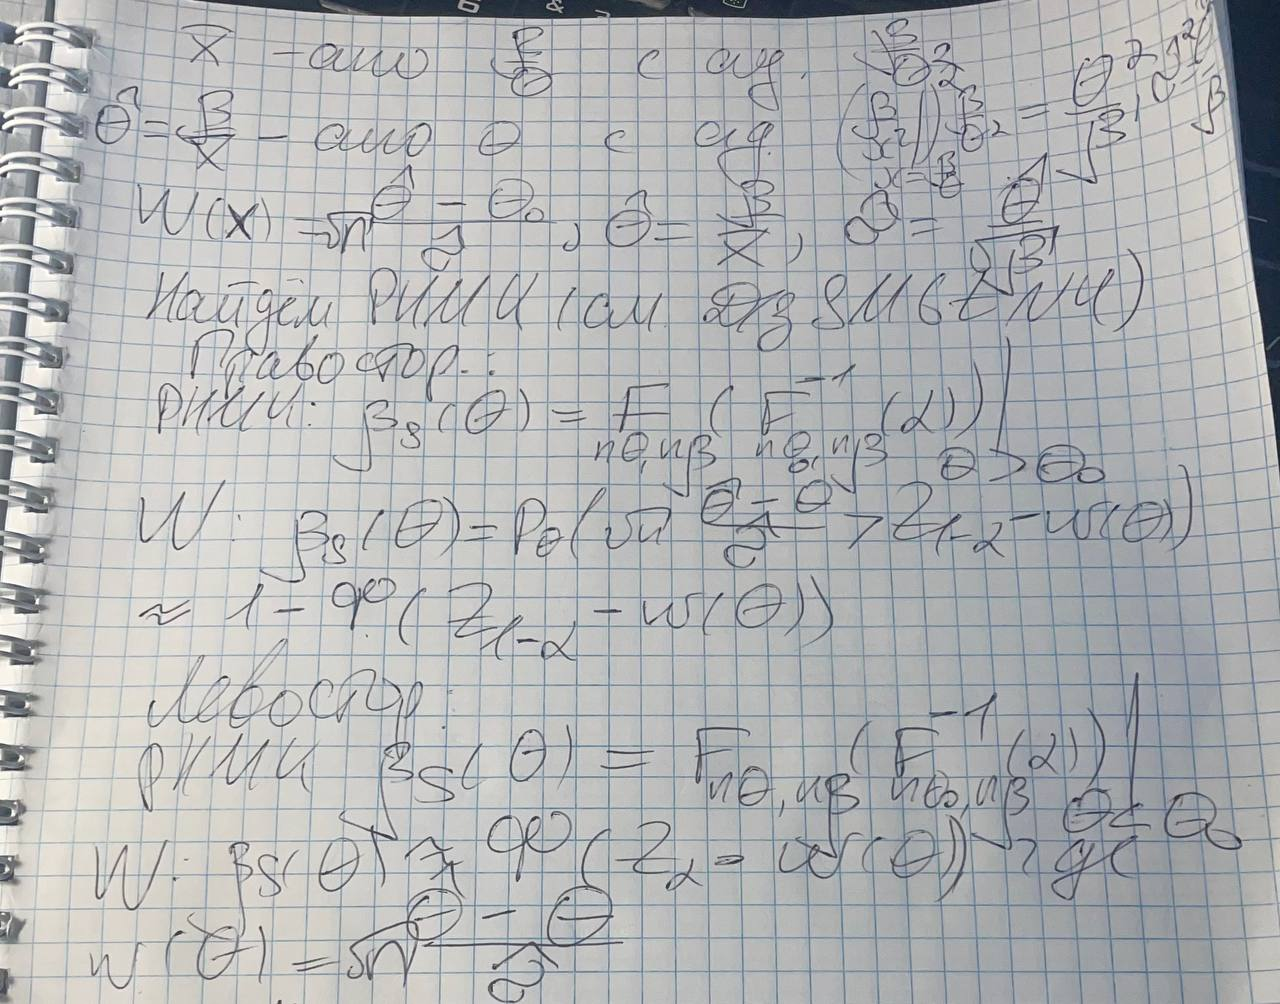

In [490]:
embed_image('3.jpg')
embed_image('4.jpg')

  0%|          | 0/5 [00:00<?, ?it/s]

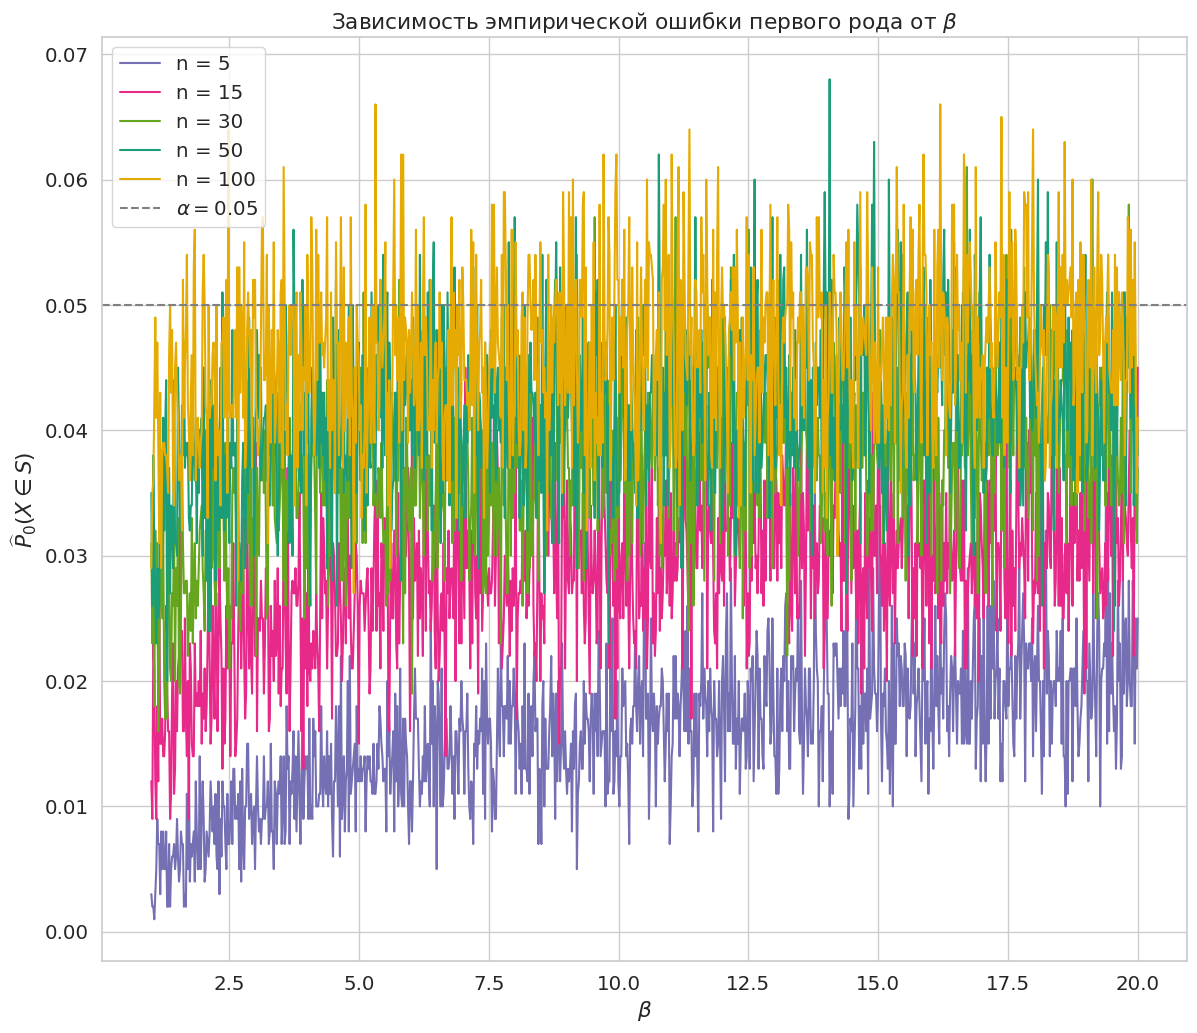

In [406]:
n_grid = [5, 15, 30, 50, 100]
t_0 = 2

alpha = 0.05
z = sps.norm.ppf(1 - alpha / 2)

m = 1000
beta_grid = np.linspace(1, 20, m)
Ws = []

plt.figure(figsize=(14, 12))
for n in tqdm(n_grid):
    p = []
    for beta in beta_grid:
        x = sps.gamma(a=beta, scale=1/t_0).rvs(size=(n, m))
        
        x_mean = np.mean(x, axis=0)
        x_mean_2 = x_mean ** 2
        x_2_mean = np.mean(x**2, axis=0)
        
        t_hat = x_mean / (x_2_mean - x_mean_2)
        b_hat = x_mean_2 / (x_2_mean - x_mean_2)
        
        sigma_hat = np.sqrt(t_hat ** 2 * (2 * b_hat + 3) / b_hat)
        
        W = (t_hat - t_0) / sigma_hat * np.sqrt(n)
        p.append(np.mean(np.abs(W) > z))
    plt.plot(beta_grid, p, label=f'n = {n}')
    plt.title(r'Зависимость эмпирической ошибки первого рода от $\beta$')
    plt.xlabel(r'$\beta$')
    plt.ylabel(r'$\widehat{P}_0(X \in S)$')
plt.axhline(alpha, color='gray', linestyle='--', label=r'$\alpha=0.05$')
plt.legend()
plt.show()

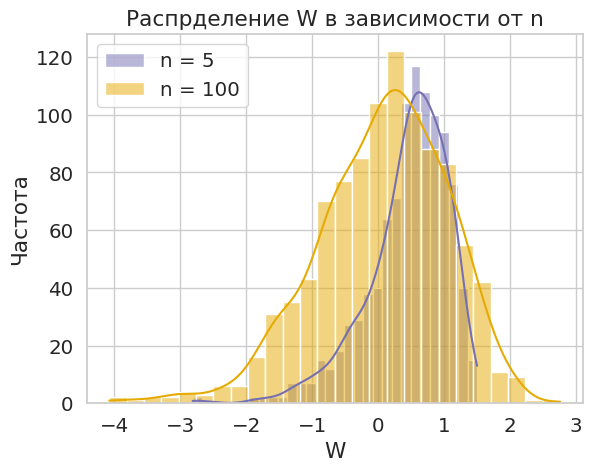

In [408]:
beta = 1
colors = ['#7570b3', '#e6ab02']
for i, n in enumerate([5, 100]):

    x = sps.gamma(a=beta, scale=1/t_0).rvs(size=(n, m))
    
    x_mean = np.mean(x, axis=0)
    x_mean_2 = x_mean ** 2
    x_2_mean = np.mean(x**2, axis=0)
    
    t_hat = x_mean / (x_2_mean - x_mean_2)
    b_hat = x_mean_2 / (x_2_mean - x_mean_2)
    
    sigma_hat = np.sqrt(t_hat ** 2 * (2 * b_hat + 3) / b_hat)
    
    W = (t_hat - t_0) / sigma_hat * np.sqrt(n)
    sns.histplot(W, kde='True', label=f'n = {n}', color=colors[i])
    plt.title(r'Распрделение W в зависимости от n')
plt.xlabel(r'W')
plt.ylabel(r'Частота')
plt.legend()
plt.show()

**Вывод:** Видим, что с ростом n ошибка колеблется около увеличивающегося до 0.05 значения, причём при малых $\beta$ около меньших, чем при больших. Это связано с получающимся распрделением W, см. картинку выше. При малых n распрделение узкое, хоть и смещённое поэтому в хвосты нормального распрделения наша статистика попадает реже. С ростом n уменьшается смещение, но распределение становится шире, то есть увеличивается его дисперсия. Также заметим, что, в отличии от задача 2.1, здесь ошибка первого рода для меньших конечных n совсем занижена

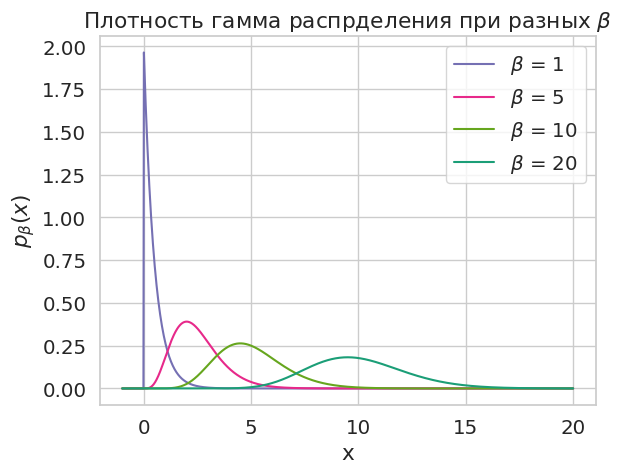

In [392]:
x = np.linspace(-1, 20, 1000)
for beta in [1, 5, 10, 20]:
    y = sps.gamma(a=beta, scale=1/t_0).pdf(x)
    plt.plot(x, y, label=rf'$\beta$ = {beta}')
plt.title(r'Плотность гамма распрделения при разных $\beta$')
plt.legend()
plt.xlabel('x')
plt.ylabel(r'$p_{\beta}(x)$')
plt.show()

**2.** Пусть $\beta$ известно. **Сравните по мощности** РНМК и критерий Вальда (*для известной $\beta$*) для левосторонней и правосторонней альтернатив, а также двусторонней альтернативы для критерия Вальда.

In [485]:
m = 1000
n = 100

alpha = 0.05
theta_0 = 2
beta = 10

#Сравнение правосторонних мощностей
right_theta_grid = np.linspace(theta_0, 3, 1000)
x = sps.gamma(a=beta, scale=1/right_theta_grid).rvs(size=(n, m))
theta_hat = beta / np.mean(x, axis=0)
sigma_hat = theta_hat / np.sqrt(beta)
    #Walde
W_power_right = 1 - sps.norm.cdf(sps.norm.cdf(1 - alpha) - np.sqrt(n) * (right_theta_grid - theta_0) / sigma_hat)
    #РНМК
most_power_right = sps.gamma(a=n * beta, scale=1/(right_theta_grid)).cdf(sps.gamma(a=n*beta, scale=1/(theta_0)).ppf(alpha))
#Левосторонних
left_theta_grid = np.linspace(1, theta_0, 1000)
x = sps.gamma(a=beta, scale=1/left_theta_grid).rvs(size=(n, m))
theta_hat = beta / np.mean(x, axis=0)
sigma_hat = theta_hat / np.sqrt(beta)
    #Walde
W_power_left = sps.norm.cdf(sps.norm.cdf(alpha) - np.sqrt(n) * (left_theta_grid - theta_0) / sigma_hat)
    #РНМК
most_power_left = 1 - sps.gamma(a=n*beta, scale=1/(left_theta_grid)).cdf(sps.gamma(a=n*beta, scale=1/(theta_0)).ppf(1-alpha))
#Двусторонний Walde
theta_grid = np.linspace(1, 3, 1000)
x = sps.gamma(a=beta, scale=1/theta_grid).rvs(size=(n, m))
theta_hat = beta / np.mean(x, axis=0)
sigma_hat = theta_hat / np.sqrt(beta)

z1 = sps.norm.ppf(1 - alpha / 2)
z2 = sps.norm.ppf(alpha / 2)
w = np.sqrt(n) * (theta_grid - theta_0) / sigma_hat

W_power_both = 1 - sps.norm.cdf(z1 - w) + sps.norm.cdf(z2 - w)

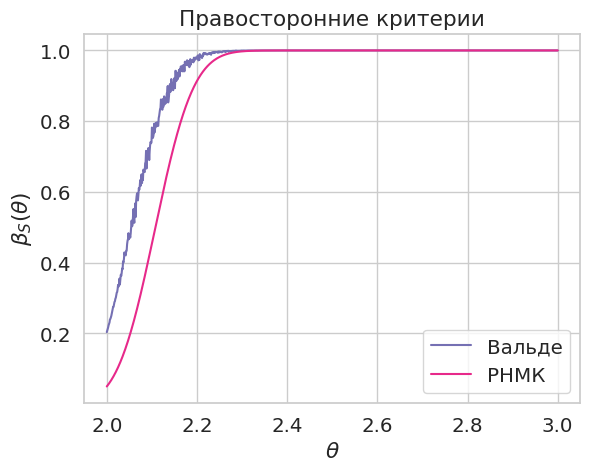

In [486]:
plt.plot(right_theta_grid, W_power_right, label='Вальде')
plt.plot(right_theta_grid, most_power_right, label='РНМК')
plt.title('Правосторонние критерии')
plt.xlabel(r'$\theta$')
plt.ylabel(r'$\beta_S(\theta)$')
plt.legend()
plt.show()

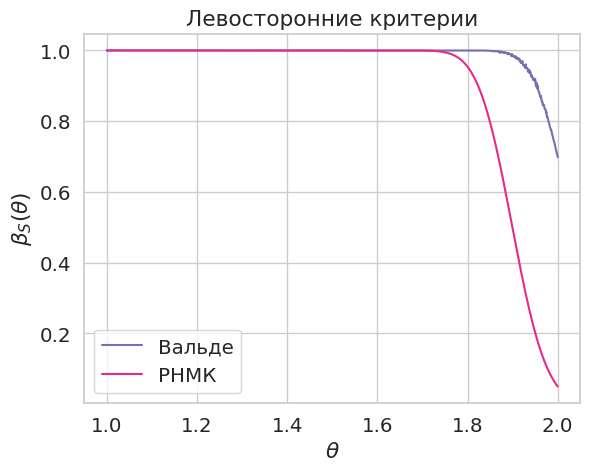

In [487]:
plt.plot(left_theta_grid, W_power_left, label='Вальде')
plt.plot(left_theta_grid, most_power_left, label='РНМК')
plt.title('Левосторонние критерии')
plt.xlabel(r'$\theta$')
plt.ylabel(r'$\beta_S(\theta)$')
plt.legend()
plt.show()

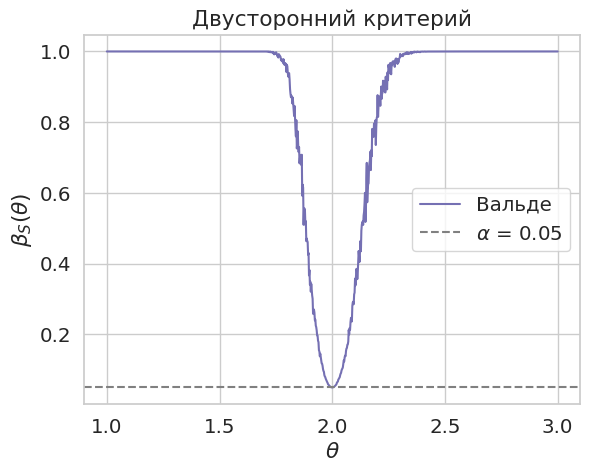

In [489]:
plt.plot(theta_grid, W_power_both, label='Вальде')
plt.title('Двусторонний критерий')
plt.xlabel(r'$\theta$')
plt.ylabel(r'$\beta_S(\theta)$')
plt.axhline(0.05, label=r'$\alpha$ = 0.05', color='gray', linestyle='--')
plt.legend()
plt.show()

**Вывод:** РНМК является таковым лишь среди тех, чья ошибка первого рода лежит ниже $\alpha$. Асимптотический Вальде на конечных выборках этого не обспечивает, поэтому можнт являться более мощным. Однако, особенно легко убедиться вблизи значения $\theta = 2$, что его ошибка первого рода сильно больше 0.05 во всех случаях, кроме двустороннего

---
© 2025 команда <a href="https://thetahat.ru/">ThetaHat</a> для DS-потока